# 02. The collected data

The data is collected by `scripts/collect_data.py`, not in this notebook, because a full run takes many hours. This notebook describes what the script produced.

```bash
python scripts/collect_data.py --events-per-series 50
```

**Provisional results.** The files currently in `data/` come from a validation run with 10 events per series. Rerun the script with a larger sample, then rerun the notebooks.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
from pmcal.collect import HORIZONS_BY_FAMILY

markets = pd.read_parquet(ROOT / "data" / "markets.parquet")
obs = pd.read_parquet(ROOT / "data" / "observations.parquet")
label_check = pd.read_csv(ROOT / "data" / "label_check.csv", index_col=0)
HORIZON_ORDER = ["1h", "1d", "7d", "30d"]
print(f"{len(markets):,} filtered markets available, {obs['ticker'].nunique():,} sampled, {len(obs):,} observations")

184,383 filtered markets available, 20,239 sampled, 38,395 observations


## 1. Label check

Within each event, how many hours earlier did Yes markets close than No markets? Series above one hour behave like deadline markets and were dropped by the script.

In [2]:
label_check.head(8).round(2)

,events,median_h,share_over_1h
series_ticker,,,
KXRANKLISTSONGSPOTUSA,29,403.05,0.97
KXSBGUESTS,9,58.47,1.00
KXRAIN,304,1.00,0.03
KXOSCARNOMPIC,17,0.15,0.00
KXTIME,9,0.09,0.00
KXNBATOTAL,2986,0.00,0.01
KXMLBTOTAL,7214,0.00,0.12
KXTOPARTIST,2,0.00,0.00


## 2. Observations by family and horizon

In [3]:
counts = obs.pivot_table(index="family", columns="horizon", values="ticker", aggfunc="size", fill_value=0)
counts[[h for h in HORIZON_ORDER if h in counts]]

horizon,1h,1d,7d,30d
family,,,,
crypto,96,19,4,9
culture,2123,2053,756,508
economics,5711,5208,1769,1215
politics,103,97,220,95
sports,0,4615,490,0
weather,6686,6618,0,0


## 3. The volume threshold

The protocol requires 10,000 contracts traded before the horizon. The share passing it rises close to resolution, when most of the trading happens.

In [4]:
obs["passes_volume"] = obs["volume_before"] >= 10_000
share = obs.pivot_table(index="family", columns="horizon", values="passes_volume", aggfunc="mean")
share[[h for h in HORIZON_ORDER if h in share]].style.format("{:.0%}")

horizon,1h,1d,7d,30d
family,,,,
crypto,16%,32%,100%,56%
culture,62%,54%,49%,34%
economics,52%,35%,59%,34%
politics,68%,60%,35%,56%
sports,nan%,17%,18%,nan%
weather,38%,1%,nan%,nan%


In [5]:
kept = obs[obs["passes_volume"]]
kept_counts = kept.pivot_table(index="family", columns="horizon", values="ticker", aggfunc="size", fill_value=0)
print("Observations kept for the analysis")
kept_counts[[h for h in HORIZON_ORDER if h in kept_counts]]

Observations kept for the analysis


horizon,1h,1d,7d,30d
family,,,,
crypto,15,6,4,5
culture,1310,1109,372,174
economics,2971,1807,1049,409
politics,70,58,76,53
sports,0,765,90,0
weather,2569,58,0,0


## 4. Price source and spread

In [6]:
print(kept.groupby("horizon")["price_source"].value_counts(normalize=True).unstack().reindex(HORIZON_ORDER).round(3))
print()
print("Median spread (cents) when the midpoint is used")
print((kept[kept["price_source"] == "mid"].groupby("horizon")["spread"].median() * 100).reindex(HORIZON_ORDER).round(1))

price_source   last    mid
horizon                   
1h            0.692  0.308
1d            0.346  0.654
7d            0.268  0.732
30d           0.184  0.816

Median spread (cents) when the midpoint is used
horizon
1h     2.0
1d     1.0
7d     2.0
30d    1.0
Name: spread, dtype: float64


## 5. Price distribution

Many observations sit near 0 or 1: bracket markets (temperature, CPI) contain several near-certain losers, and some horizons are close to resolution.

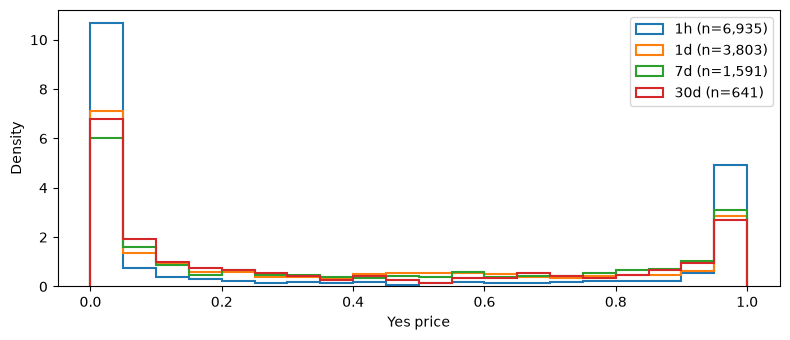

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3.5))
for h in HORIZON_ORDER:
    s = kept.loc[kept["horizon"] == h, "price"]
    if len(s):
        ax.hist(s, bins=20, range=(0, 1), histtype="step", lw=1.5, density=True, label=f"{h} (n={len(s):,})")
ax.set_xlabel("Yes price")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
fig.savefig(ROOT / "figures" / "price_distribution.png", dpi=150)
plt.show()